<a href="https://colab.research.google.com/github/KushagraPan/A-Curated-List-of-ML-System-Design-Case-Studies/blob/main/Car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [334]:
import pandas as pd
import numpy as np

In [406]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'


In [407]:
df= pd.read_csv(data)
df.head(5)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [408]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


In [409]:
df.isnull().sum()

,0
model_year,0
origin,0
fuel_type,0
drivetrain,0
num_doors,0
engine_displacement,0
num_cylinders,0
horsepower,877
vehicle_weight,0
acceleration,264


In [338]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [339]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [340]:
df.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


In [341]:
df.dtypes[df.dtypes == 'object']

,0
make,object
model,object
engine_fuel_type,object
transmission_type,object
driven_wheels,object
market_category,object
vehicle_size,object
vehicle_style,object


In [342]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [343]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ','_')

df[col]

,vehicle_style
0,coupe
1,convertible
2,coupe
3,coupe
4,convertible
...,...
11909,4dr_hatchback
11910,4dr_hatchback
11911,4dr_hatchback
11912,4dr_hatchback


In [344]:
df.make

,make
0,bmw
1,bmw
2,bmw
3,bmw
4,bmw
...,...
11909,acura
11910,acura
11911,acura
11912,acura


In [345]:
df.head(5)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [346]:
for col in df.columns:
  print(col)
  print(df[col].unique()[:5])
  print(df[col].nunique())
  print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [347]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

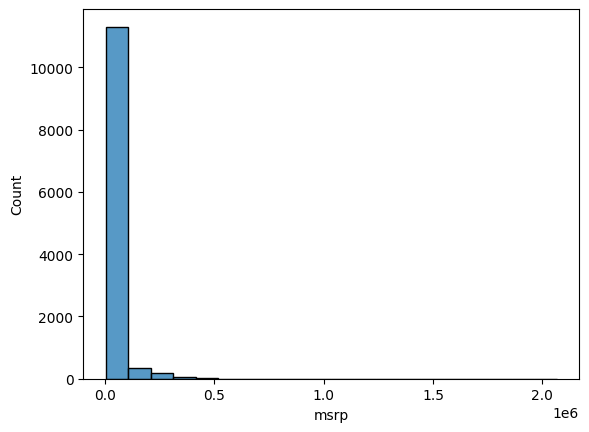

In [348]:
sns.histplot(df.msrp,bins=20)


<Axes: xlabel='msrp', ylabel='Count'>

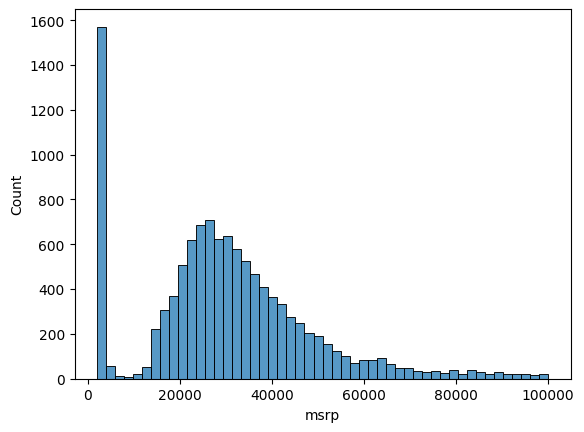

In [349]:
sns.histplot(df.msrp[df.msrp<100000],bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

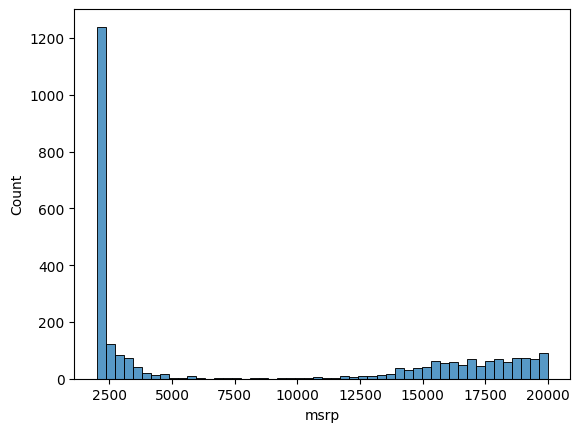

In [350]:
sns.histplot(df.msrp[df.msrp<20000],bins=50)

In [351]:
np.log([0, 0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])

/tmp/ipykernel_3745/1084440297.py:1: RuntimeWarning: divide by zero encountered in log
  np.log([0, 0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100000 + 1])


array([       -inf,  0.        ,  0.69314718,  2.39789527,  6.90875478,
       11.51293546])

In [352]:
df.msrp.describe()

,msrp
count,1.191400e+04
mean,4.059474e+04
std,6.010910e+04
min,2.000000e+03
25%,2.100000e+04
50%,2.999500e+04
75%,4.223125e+04
max,2.065902e+06


In [353]:
price_logs = np.log1p(df.msrp)
price_logs

,msrp
0,10.739349
1,10.612779
2,10.500977
3,10.290483
4,10.448744
...,...
11909,10.739024
11910,10.945018
11911,10.832122
11912,10.838031


<Axes: xlabel='msrp', ylabel='Count'>

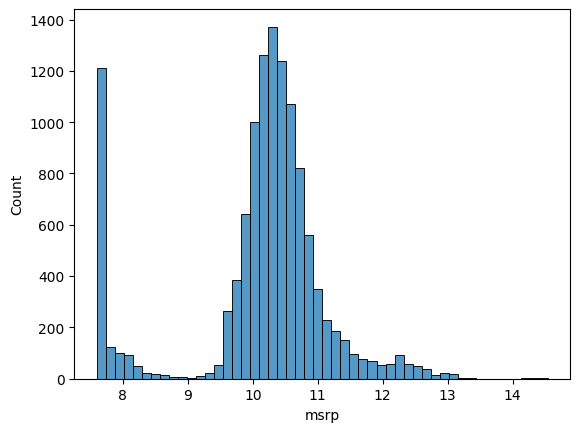

In [354]:
sns.histplot(price_logs,bins=50)

In [355]:
df.isnull().sum()

,0
make,0
model,0
year,0
engine_fuel_type,3
engine_hp,69
engine_cylinders,30
transmission_type,0
driven_wheels,0
number_of_doors,6
market_category,3742


In [356]:
#df.market_category =df.market_category.fillna('Unknown')
#df.market_category.isnull().sum()'''

In [357]:
#df.number_of_doors=df.number_of_doors.fillna((df.number_of_doors.mode()[0]))
#df.number_of_doors.isnull().sum()'''

In [358]:
#df.engine_fuel_type=df.engine_fuel_type.fillna(lambda x: x.median())
#df.engine_fuel_type.isnull().sum()

In [359]:
# df['engine_hp'] = df.groupby('make')['engine_hp'].transform(lambda x: x.fillna(x.median()))
#df['engine_cylinders'] = df.groupby('make')['engine_cylinders'].transform(lambda x: x.fillna(x.median()))



In [360]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [361]:
n , n_val, n_test, n_train


(11914, 2382, 2382, 7150)

In [362]:
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)
idx

array([7956, 8127, 9167, ..., 6782, 4444, 8574])

In [363]:
df_train = df.iloc[idx[:n_train]]
print(idx[:n_train])
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

[ 7956  8127  9167 ...  1670 11332  7736]


In [364]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [365]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)




In [366]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)



In [367]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [368]:
def train_linear_regression(X, y):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])
  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(y)
  return w_full[0], w_full[1:]

### **Baseline Model**

In [369]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [370]:
base = ['engine_hp','engine_cylinders',  'highway_mpg', 'city_mpg','popularity']

In [371]:
X_train = df_train[base].values


In [372]:
w0 ,w = train_linear_regression(X_train, y_train)
w0 ,w

(np.float64(nan), array([nan, nan, nan, nan, nan]))

In [373]:
df_train[base].isnull().sum()

,0
engine_hp,38
engine_cylinders,21
highway_mpg,0
city_mpg,0
popularity,0


In [374]:
X_train = df_train[base].fillna(0).values



In [375]:
w0 ,w = train_linear_regression(X_train, y_train)
w0, w


(np.float64(7.336190877371047),
 array([ 9.39008342e-03, -1.10973993e-01,  4.75929656e-02, -9.57980243e-03,
        -5.95356785e-06]))

In [376]:
y_pred = w0 +X_train.dot(w)
y_pred


array([11.0210432 ,  8.89194852,  8.90411741, ...,  9.30003051,
        9.51059803,  9.8957623 ])

<Axes: ylabel='Count'>

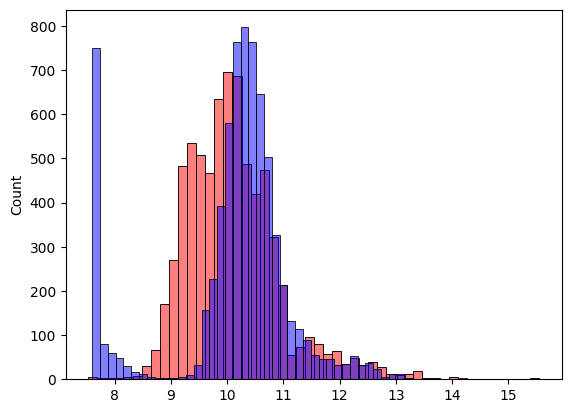

In [377]:
sns.histplot(y_pred,bins=50,color='red',alpha=0.5)
sns.histplot(y_train,bins=50,color='blue',alpha=0.5)

In [378]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [379]:
rmse(y_train, y_pred)

np.float64(0.7482711106202532)

In [380]:
def prepare(df):
  df_num = df[base]
  df_num = df_num.fillna(0)
  X = df_num.values
  return X


In [381]:
X_train = prepare(df_train)
w0 ,w = train_linear_regression(X_train, y_train)
X_val = prepare(df_val)
y_pred = w0 +X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.7504715722048921)

### **FEATURE** **ENGINEERING**


In [382]:
def prepare_X(df):
    df_copy= df.copy()
    df_copy['age'] = 2017 - df_copy.year
    features = base + ['age']

    df_num = df_copy[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [383]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5252296112385284)

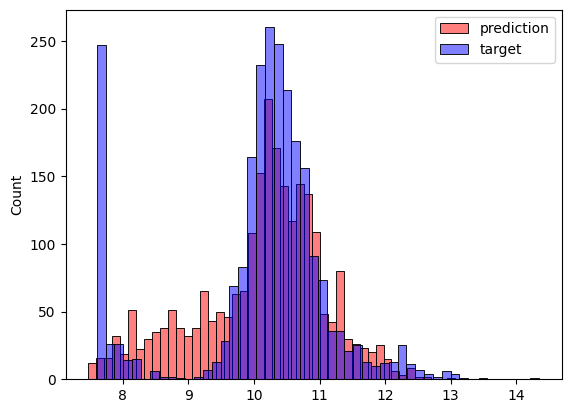

In [384]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

In [385]:
df_train.number_of_doors == 2

,number_of_doors
0,False
1,False
2,False
3,True
4,False
...,...
7145,True
7146,False
7147,False
7148,False


In [386]:
def prepare_X(df):
    df_copy= df.copy()
    df_copy['age'] = 2017 - df_copy.year

    features = base + ['age']

    for v in [2,3,4]:
      df_copy[f'num_doors_{v}'] = (df_copy.number_of_doors == v).astype('int')
      features.append(f'num_doors_{v}')



    df_num = df_copy[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [387]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5231112534614689)

In [388]:
df.make.value_counts().head()

,count
make,
chevrolet,1123
ford,881
volkswagen,809
toyota,746
dodge,626


In [389]:
makes = list(df.make.value_counts().head().index)
makes

['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

In [390]:
def prepare_X(df):
    df_copy= df.copy()
    df_copy['age'] = 2017 - df_copy.year

    features = base + ['age']

    for v in [2,3,4]:
      df_copy[f'num_doors_{v}'] = (df_copy.number_of_doors == v).astype('int')
      features.append(f'num_doors_{v}')

    for v in makes:
      df_copy[f'make_is_{v}'] = (df_copy.make == v).astype('int')
      features.append(f'make_is_{v}')

    df_num = df_copy[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [391]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5151034415557716)

In [392]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().head().index)

In [393]:
def prepare_X(df):
    df_copy= df.copy()
    df_copy['age'] = 2017 - df_copy.year

    features = base + ['age']

    for v in [2,3,4]:
      df_copy[f'num_doors_{v}'] = (df_copy.number_of_doors == v).astype('int')
      features.append(f'num_doors_{v}')
    for c,values in categories.items():
      for v in values:
        df_copy[f'{c}_is_{v}'] = (df_copy[c] == v).astype('int')
        features.append(f'{c}_is_{v}')

    df_num = df_copy[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [394]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(40.66748272441607)

## **Regularisation**

In [395]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [396]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4715059763900519)

In [397]:
for r in [0, 0.000001, 0.001, 0.1, 1, 10]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0 + X_val.dot(w)

    print(f'r is {r} , w0 is {w0} ',  rmse(y_val, y_pred))

r is 0 , w0 is -628893143147887.8  40.66748272441607
r is 1e-06 , w0 is 598.2890650106277  0.47150386464444227
r is 0.001 , w0 is 6.669431639906116  0.4715059763900519
r is 0.1 , w0 is 6.5189180353841465  0.4716759256948469
r is 1 , w0 is 5.760188310945311  0.4731772560779304
r is 10 , w0 is 4.229313355025897  0.4864746266817789


In [398]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

np.float64(0.4715059763900519)

## **Training the final model**

In [399]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
df_full_train.shape

(9532, 15)

In [400]:
X_full_train = prepare_X(df_full_train)
X_full_train.shape

(9532, 41)

In [401]:
y_full_train = np.concatenate([y_train, y_val])

In [402]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [403]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

np.float64(0.5068292565958078)